# **DIABETES PREDICTION USING LOGISTIC REGRESSION**

## **Importing necessary libraries**

In [164]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## **Importing the Diabetes dataset**

In [165]:
diabetes_dataset = pd.read_csv("diabetes.csv")
diabetes_dataset.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## **Shape of the Diabetes dataset**

In [166]:
print(f"Shape of the diabetes dataset: {diabetes_dataset.shape}")
print()
print(f"Number of rows in the dataset: {diabetes_dataset.shape[0]}")
print(f"Number of columns in the dataset: {diabetes_dataset.shape[1]}")

Shape of the diabetes dataset: (768, 9)

Number of rows in the dataset: 768
Number of columns in the dataset: 9


## **Statistical information about the Diabetes dataset**

In [167]:
print(diabetes_dataset.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

## **Checking null values and missing values**

In [168]:
print("Number of null values in each column")
print(diabetes_dataset.isnull().sum())

Number of null values in each column
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## **Data type information about features**

In [169]:
print(diabetes_dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


## **Description about the features in the Diabetes dataset**

In [170]:
print("Pregnancies: To express the Number of pregnancies")
print("Glucose: To express the Glucose level in blood")
print("BloodPressure: To express the Blood pressure measurement")
print("SkinThickness: To express the thickness of the skin")
print("Insulin: To express the Insulin level in blood")
print("BMI: To express the Body mass index")
print("DiabetesPedigreeFunction: To express the Diabetes percentage")
print("Age: To express the age")
print("Outcome: To express the final result 1 is Yes and 0 is No")

Pregnancies: To express the Number of pregnancies
Glucose: To express the Glucose level in blood
BloodPressure: To express the Blood pressure measurement
SkinThickness: To express the thickness of the skin
Insulin: To express the Insulin level in blood
BMI: To express the Body mass index
DiabetesPedigreeFunction: To express the Diabetes percentage
Age: To express the age
Outcome: To express the final result 1 is Yes and 0 is No


In [171]:
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## **Class distribution**

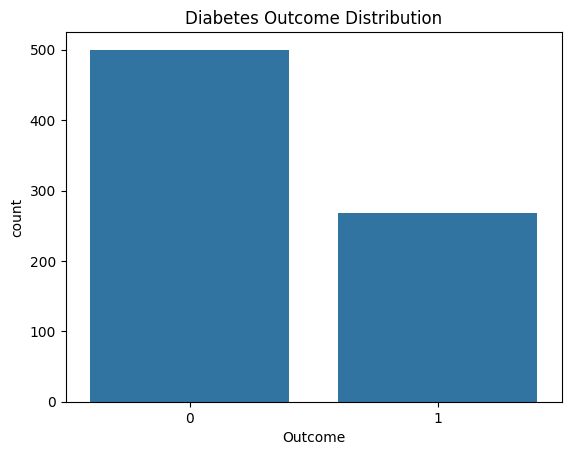

In [172]:
sns.countplot(x='Outcome', data = diabetes_dataset)
plt.title("Diabetes Outcome Distribution")
plt.show()

## **Distribution of every feature**

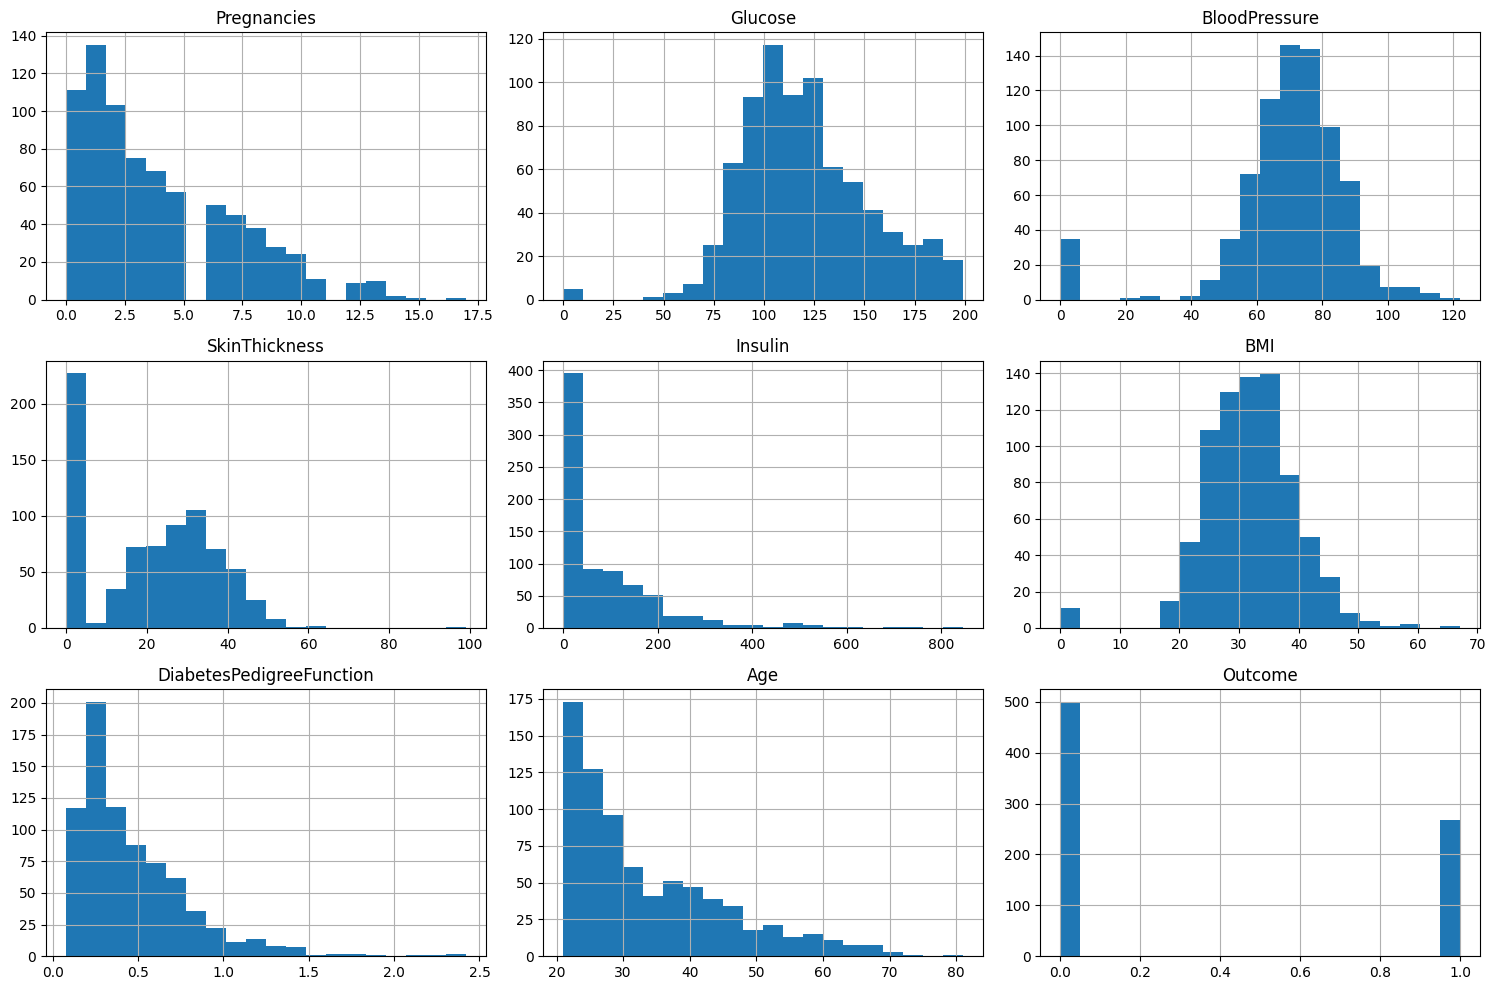

In [173]:
diabetes_dataset.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

## **Correlation Heatmap**

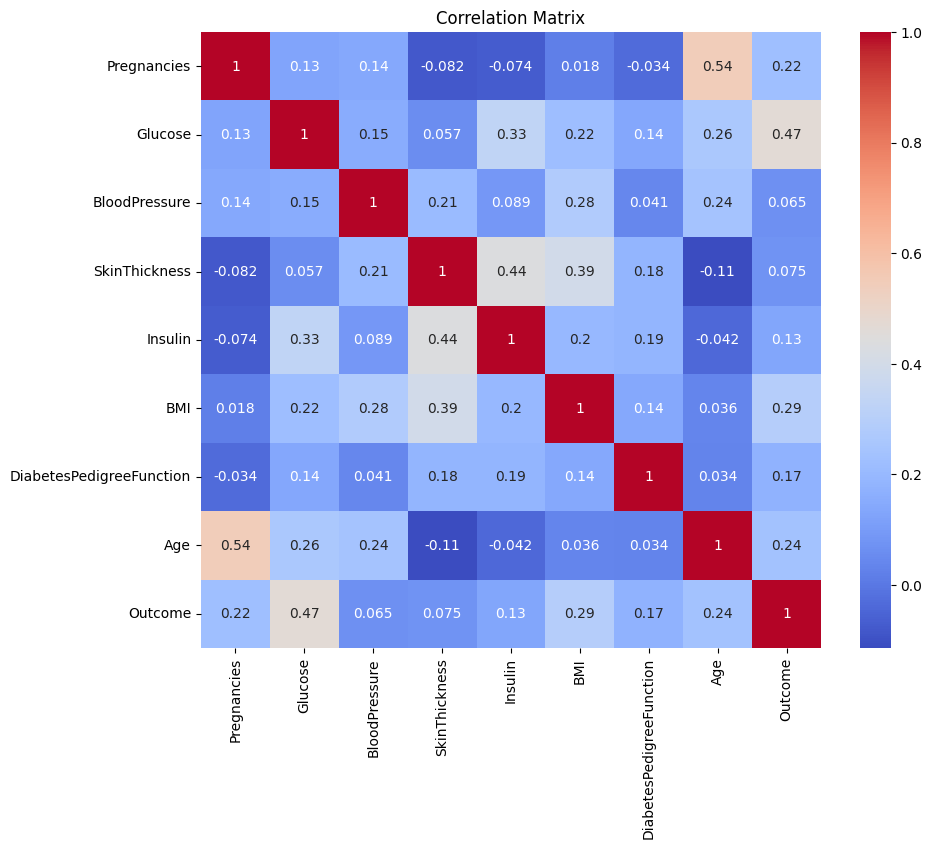

In [174]:
plt.figure(figsize=(10,8))
sns.heatmap(diabetes_dataset.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## **Scatter plot**

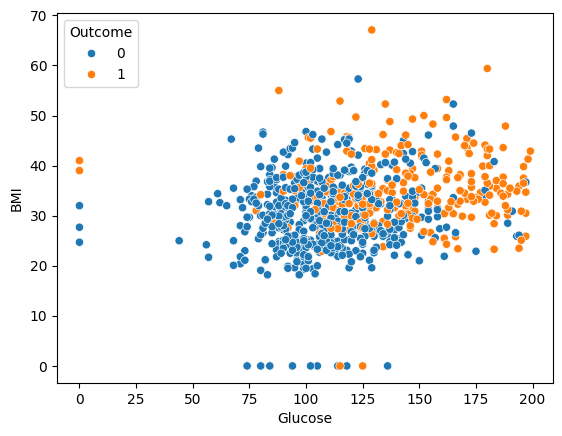

In [175]:
sns.scatterplot(x = 'Glucose',
                y = 'BMI',
                hue = 'Outcome',
                data = diabetes_dataset)

plt.show()

## **Removing absolute zero values with some arbitrary values**

In [176]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    print(f"{col}: {(diabetes_dataset[col] == 0).sum()}")

diabetes_dataset[cols] = diabetes_dataset[cols].replace(0, np.nan)

print(diabetes_dataset[cols].isnull().sum())

for col in cols:
    diabetes_dataset[col] = diabetes_dataset[col].fillna(diabetes_dataset[col].median())

print(diabetes_dataset[cols].isnull().sum())

Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## **Splitting the dataset into training set and testing set**

In [177]:
X = diabetes_dataset[["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]]
y = diabetes_dataset["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

## **Creating and training the Logistic Regression model**

In [178]:
logistic_regression_model = LogisticRegression(max_iter = 1000)
logistic_regression_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## **Testing and Evaluating the Logistic Regression model**

In [179]:
y_prediction = logistic_regression_model.predict(X_test)

print(f"Precision score: {precision_score(y_test, y_prediction)}")
print(f"Recall score: {recall_score(y_test, y_prediction)}")
print(f"F1 score: {f1_score(y_test, y_prediction)}")
print()
print("Confusion matrix: ")
print(confusion_matrix(y_test, y_prediction))
print()
print("Classification report: ")
print(classification_report(y_test, y_prediction))

Precision score: 0.6666666666666666
Recall score: 0.6181818181818182
F1 score: 0.6415094339622641

Confusion matrix: 
[[82 17]
 [21 34]]

Classification report: 
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



## **Taking input from the user**

In [180]:
print("Enter the patient's details:\n")

pregnancies = int(input("Pregnancies: "))
glucose = float(input("Glucose: "))
blood_pressure = float(input("Blood Pressure: "))
skin_thickness = float(input("Skin Thickness: "))
insulin = float(input("Insulin: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = int(input("Age: "))

Enter the patient's details:

Pregnancies: 2
Glucose: 150
Blood Pressure: 70
Skin Thickness: 35
Insulin: 120
BMI: 31.5
Diabetes Pedigree Function: 0.45
Age: 40


## **Preparing input for the prediction**

In [181]:
input_data = np.array([[pregnancies,
                        glucose,
                        blood_pressure,
                        skin_thickness,
                        insulin,
                        bmi,
                        dpf,
                        age]])

## **Prediction and printing the result**

In [182]:
prediction = logistic_regression_model.predict(input_data)
probability = logistic_regression_model.predict_proba(input_data)

print("\nPrediction:", prediction[0])

if prediction[0] == 1:
    print("The patient is likely to have Diabetes.")
else:
    print("The patient is not likely to have Diabetes.")

print(f"Probability of Non-Diabetic : {probability[0][0]:.2%}")
print(f"Probability of Diabetic     : {probability[0][1]:.2%}")


Prediction: 1
The patient is likely to have Diabetes.
Probability of Non-Diabetic : 42.22%
Probability of Diabetic     : 57.78%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
